### **Credit_Card Customer_Segmentation By Mean Shift**
---

In [18]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.cluster import MeanShift, estimate_bandwidth

In [2]:
df=pd.read_csv('credit_card_customer_data.csv')

#### **Data Understanding**
---

In [3]:
df.head()

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1,87073,100000,2,1,1,0
1,2,38414,50000,3,0,10,9
2,3,17341,50000,7,1,3,4
3,4,40496,30000,5,1,1,4
4,5,47437,100000,6,0,12,3


In [4]:
df.shape

(660, 7)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 660 entries, 0 to 659
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Sl_No                660 non-null    int64
 1   Customer Key         660 non-null    int64
 2   Avg_Credit_Limit     660 non-null    int64
 3   Total_Credit_Cards   660 non-null    int64
 4   Total_visits_bank    660 non-null    int64
 5   Total_visits_online  660 non-null    int64
 6   Total_calls_made     660 non-null    int64
dtypes: int64(7)
memory usage: 36.2 KB


In [6]:
df.dtypes

Sl_No                  int64
Customer Key           int64
Avg_Credit_Limit       int64
Total_Credit_Cards     int64
Total_visits_bank      int64
Total_visits_online    int64
Total_calls_made       int64
dtype: object

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Sl_No,660.0,330.500000,190.669872,1.0,165.75,330.5,495.25,660.0
Customer Key,660.0,55141.443939,25627.772200,11265.0,33825.25,53874.5,77202.50,99843.0
Avg_Credit_Limit,660.0,34574.242424,37625.487804,3000.0,10000.00,18000.0,48000.00,200000.0
Total_Credit_Cards,660.0,4.706061,2.167835,1.0,3.00,5.0,6.00,10.0
Total_visits_bank,660.0,2.403030,1.631813,0.0,1.00,2.0,4.00,5.0
Total_visits_online,660.0,2.606061,2.935724,0.0,1.00,2.0,4.00,15.0
Total_calls_made,660.0,3.583333,2.865317,0.0,1.00,3.0,5.00,10.0


In [8]:
df.isnull().sum()

Sl_No                  0
Customer Key           0
Avg_Credit_Limit       0
Total_Credit_Cards     0
Total_visits_bank      0
Total_visits_online    0
Total_calls_made       0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.nunique()

#5 Customer Keys repeated with different attributes, kept

Sl_No                  660
Customer Key           655
Avg_Credit_Limit       110
Total_Credit_Cards      10
Total_visits_bank        6
Total_visits_online     16
Total_calls_made        11
dtype: int64

#### **EDA & Data Preprocessing**
---

In [11]:
df = df.drop(columns=['Sl_No', 'Customer Key']).reset_index(drop=True)
features = df.columns.tolist()

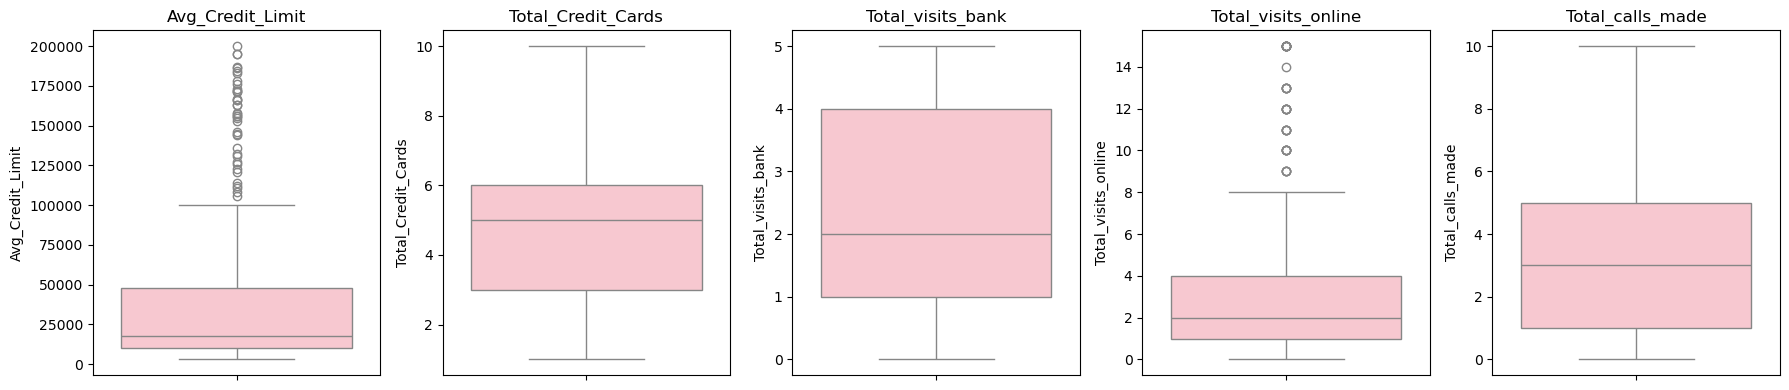

In [12]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for a, c in zip(axes, features):
    sns.boxplot(y=df[c], ax=a, color="pink")
    a.set_title(c)
plt.tight_layout()
plt.show()

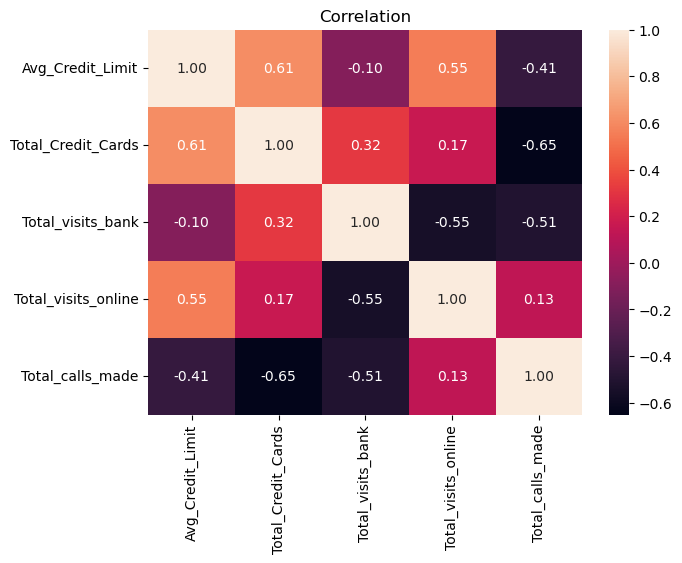

In [13]:
plt.figure(figsize=(7, 5))
sns.heatmap(df.corr(), annot=True, fmt='.2f')
plt.title('Correlation')
plt.show()

In [14]:
X = df.copy()
X['Avg_Credit_Limit'] = np.log1p(X['Avg_Credit_Limit'])

In [15]:
X_scaled = pd.DataFrame(StandardScaler().fit_transform(X), columns=features)
X_scaled.head()

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1.630500,-1.249225,-0.860451,-0.547490,-1.251537
1,0.885383,-0.787585,-1.473731,2.520519,1.891859
2,0.885383,1.058973,-0.860451,0.134290,0.145528
3,0.336263,0.135694,-0.860451,-0.547490,0.145528
4,1.630500,0.597334,-1.473731,3.202298,-0.203739


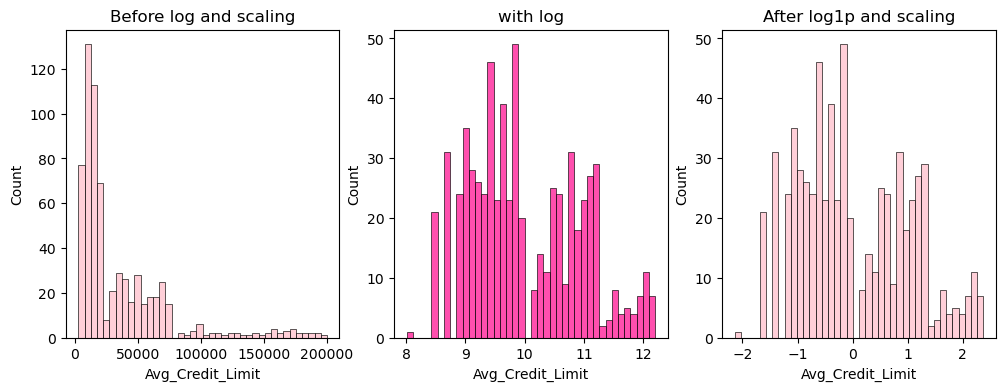

In [16]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

sns.histplot(df['Avg_Credit_Limit'], bins=40, ax=ax[0], color="pink")
sns.histplot(X['Avg_Credit_Limit'], bins=40, ax=ax[1], color="deeppink")
sns.histplot(X_scaled['Avg_Credit_Limit'], bins=40, ax=ax[2], color="pink")

ax[0].set_title('Before log and scaling'); 
ax[1].set_title('with log'); 
ax[2].set_title('After log1p and scaling')
plt.show()

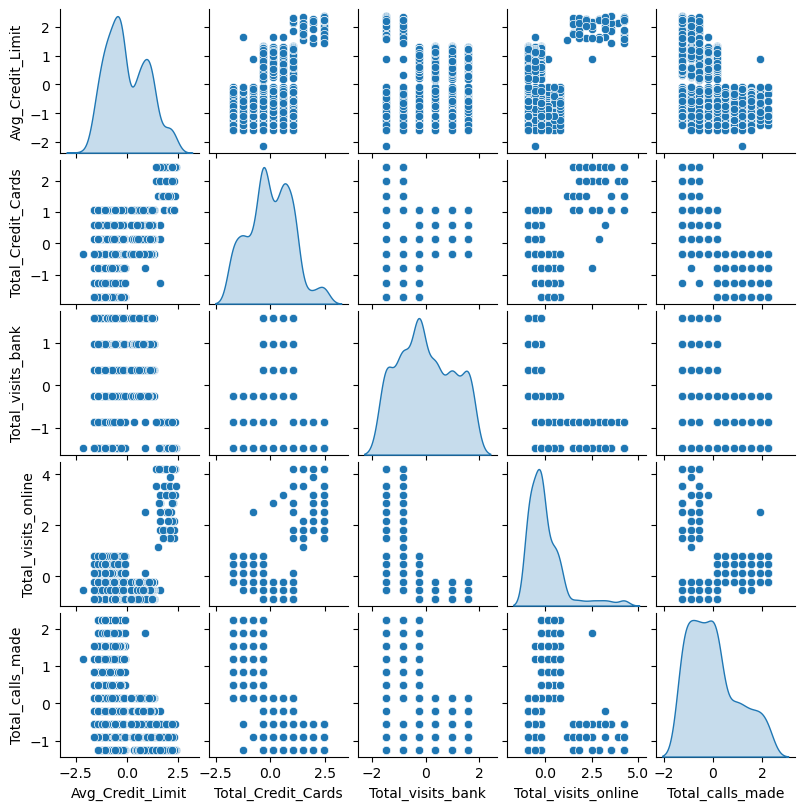

In [17]:
g = sns.pairplot(X_scaled, diag_kind="kde")
g.figure.set_size_inches(8, 8)

#### **Mean Shift**
---

In [25]:
rows = []
for q in [0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5]:
    bw = estimate_bandwidth(X_scaled, quantile=q, random_state=42)
    labels = MeanShift(bandwidth=bw, bin_seeding=True).fit_predict(X_scaled)
    n = len(np.unique(labels))
    sizes = sorted(pd.Series(labels).value_counts(), reverse=True)
    sil = silhouette_score(X_scaled, labels)
    rows.append({'quantile': q, 'bandwidth': round(bw, 2), 'n_clusters': n,
                 'sizes': sizes[:8], 'silhouette': round(sil, 3)})

ms_res = pd.DataFrame(rows)
ms_res

,quantile,bandwidth,n_clusters,sizes,silhouette
0,0.10,1.47,4,"[382, 227, 50, 1]",0.460
1,0.15,1.65,4,"[384, 225, 50, 1]",0.462
2,0.20,1.80,3,"[385, 225, 50]",0.493
3,0.25,1.94,3,"[385, 225, 50]",0.493
4,0.30,2.10,3,"[385, 225, 50]",0.493
5,0.40,2.50,2,"[609, 51]",0.499
6,0.50,2.79,2,"[609, 51]",0.499


In [ ]:
# Quantile (in estimate_bandwidth): a number between 0 and 1 that sets the bandwidth for MeanShift. 
# For each customer, the function looks at the nearest quantile × 100% of customers (e.g., 0.2 means the closest 20%), 
# measures the distance to the farthest of them, and averages these distances across all customers. 
# A smaller quantile gives a smaller bandwidth and more clusters; 
# a larger quantile gives a larger bandwidth and fewer clusters.

#### **The Final Model**
---

In [26]:
from sklearn.metrics import adjusted_rand_score, davies_bouldin_score, calinski_harabasz_score

bw = estimate_bandwidth(X_scaled, quantile=0.25, random_state=42)
ms = MeanShift(bandwidth=bw, bin_seeding=True).fit(X_scaled)
df['Cluster_MS'] = ms.labels_

In [27]:
# Choice of `quantile` (bandwidth). Quantile values 0.20, 0.25 and 0.30 (bandwidth 1.80-2.10)
# all produced the same 3 clusters (sizes 385 / 225 / 50, Silhouette = 0.493), so the result
# does not depend on one exact value. We selected the middle of this stable range,
# `quantile=0.25` (bandwidth ≈ 1.94). Smaller values (0.10, 0.15) split off a cluster
# containing a single customer, which is an outlier rather than a segment. Larger values
# (0.40, 0.50) merged the two bigger groups into one (sizes 609 / 51), losing
# the distinction between them. The choice was based on stability and cluster sizes

#### **Evaluation**
---

In [28]:
lab = df['Cluster_MS']
print("Silhouette:", round(silhouette_score(X_scaled, lab), 3))
print("Davies-Bouldin:", round(davies_bouldin_score(X_scaled, lab), 3))
print("Calinski-Harabasz:", round(calinski_harabasz_score(X_scaled, lab), 1))

Silhouette: 0.493
Davies-Bouldin: 0.729
Calinski-Harabasz: 665.7


#### **Profiling**
---

In [30]:
print(df['Cluster_MS'].value_counts().sort_index())

Cluster_MS
0    385
1    225
2     50
Name: count, dtype: int64


In [40]:
profile = df.groupby('Cluster_MS')[features].mean().round(1)
profile.insert(0, 'Customers', df['Cluster_MS'].value_counts())
profile.insert(1, 'Share %', (profile['Customers'] / len(df) * 100).round(1))

(profile.style
    .background_gradient(cmap='RdPu', subset=features, axis=0)
    .format(precision=1)
    .set_caption('MeanShift cluster profile'))

,Customers,Share %,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
Cluster_MS,,,,,,,
0,385,58.3,33851.9,5.5,3.5,1.0,2.0
1,225,34.1,12151.1,2.4,0.9,3.5,6.9
2,50,7.6,141040.0,8.7,0.6,10.9,1.1


#### **Naming the Segments**
---

In [47]:
means_ms = df.groupby('Cluster_MS')[features].mean()

names_ms = {}
names_ms[means_ms['Avg_Credit_Limit'].idxmax()] = 'High-Limit Online'
names_ms[means_ms['Total_calls_made'].idxmax()]  = 'Phone-Reliant'
names_ms[means_ms['Total_visits_bank'].idxmax()] = 'Branch-Oriented'

df['Segment_MS'] = df['Cluster_MS'].map(names_ms)
print(df['Segment_MS'].value_counts())

Segment_MS
Branch-Oriented      385
Phone-Reliant        225
High-Limit Online     50
Name: count, dtype: int64


In [45]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
var = pca.explained_variance_ratio_
print("Explained variance:", var.round(2), "| total:", var.sum().round(2))

Explained variance: [0.47 0.33] | total: 0.8


In [ ]:
# PC1 explains 47% and PC2 explains 33% of the variance.
# Together, they capture 80% of the total variance, meaning that the 2D representation
# retains most of the important information in the original dataset.

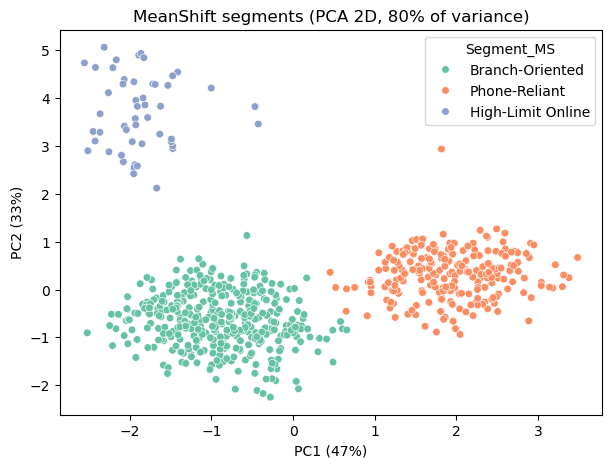

In [ ]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['Segment_MS'], palette='Set2', s=30)
plt.xlabel(f'PC1 ({var[0]:.0%})')
plt.ylabel(f'PC2 ({var[1]:.0%})')
plt.title(f'MeanShift segments (PCA 2D, {var.sum():.0%} of variance)')
plt.show()